# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Fabian Leong 2500344C



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import randint, uniform


# 1. Business Understanding
Goal: To find the how much insurance would cost based on certain factors

# 2. Data Understanding

## 2.1 Load dataset

In [2]:
## Read *.csv file into pandas DataFrame
FILE_PATH = "insurance.csv"
df = pd.read_csv(FILE_PATH) 
df ## Display dataframe

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## 2.2 Summary Statistics

In [3]:
## Understand the type of variable for each column
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [4]:
## Check for missing data
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [5]:
## Describe data distribution
df.describe(include="all")


,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

<Axes: xlabel='charges', ylabel='Count'>

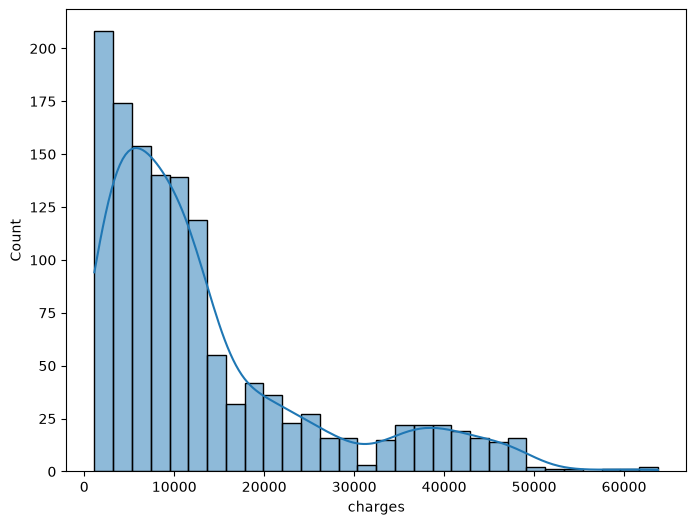

In [4]:
## Understanding distribution of target
col_y = "charges"

plt.figure(figsize=(8, 6))
sns.histplot(df[col_y], kde=True, bins=30)

The target variable is right-skewed, with most values clustered at lower charges and a few very high values. The distribution is not normal and contains several high-value outliers.

### 2.3.1.2 Understanding distribution of features

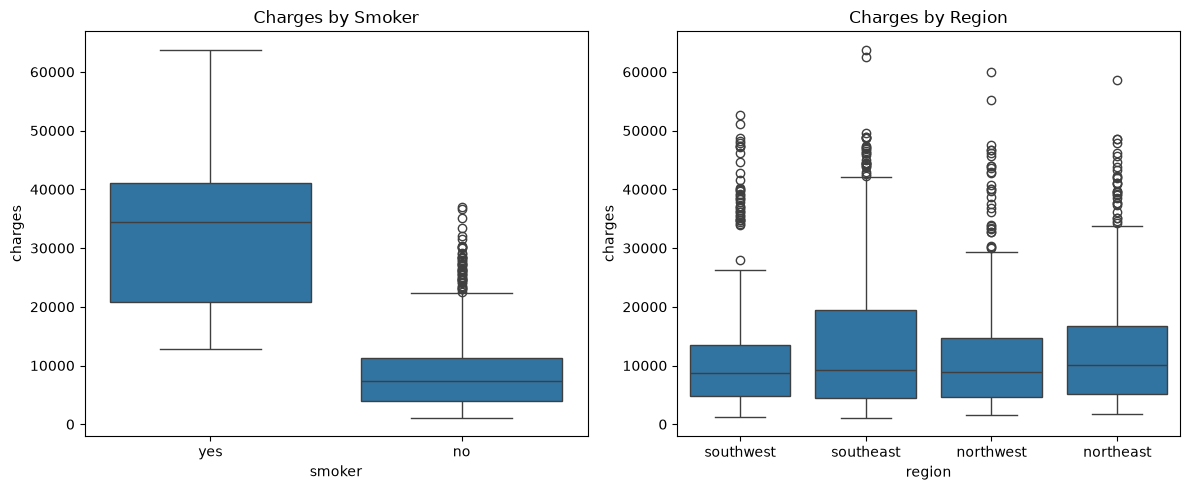

In [7]:
## Understanding distribution of features
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x="smoker", y="charges")
plt.title("Charges by Smoker")

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x="region", y="charges")
plt.title("Charges by Region")

plt.tight_layout()

The boxplot shows that smokers have significantly higher charges than non-smokers. The median and interquartile range for smokers are much higher, indicating that smoking is strongly associated with increased insurance costs. Non-smokers generally have lower charges, although there are several high-cost outliers. The distribution of charges is fairly similar across all four regions, with comparable medians and spreads. While the southeast region appears to have a slightly higher median and more extreme high-cost outliers, the differences between regions are relatively small. This suggests that region has a weaker influence on medical charges compared to smoking status. Overall, the boxplots indicate that smoking has a much stronger impact on insurance charges than region, making it a more important feature for predicting medical costs.

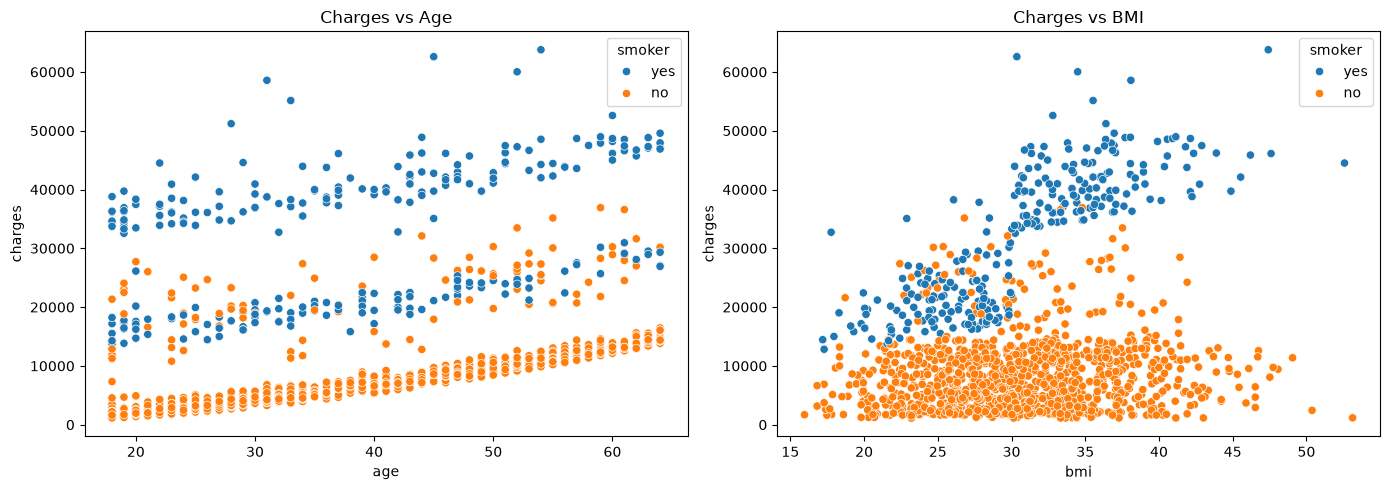

In [8]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x="age", y="charges", hue="smoker")
plt.title("Charges vs Age")

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker")
plt.title("Charges vs BMI")

plt.tight_layout()

The scatter plot shows a positive relationship between age and charges, where charges generally increase as age increases. Smokers consistently incur much higher charges than non-smokers across all age groups. This suggests that both age and smoking status are important predictors of insurance charges. There is a moderate positive relationship between BMI and medical charges, particularly among smokers. Smokers with higher BMI tend to have the highest medical charges, while non-smokers generally maintain lower charges regardless of BMI. This indicates a possible interaction between BMI and smoking, where having both risk factors leads to substantially higher insurance costs. Overall, the scatter plots suggest that age, BMI, and smoking status all influence medical charges, with smoking showing the strongest effect. Older individuals and smokers with higher BMI are more likely to incur higher insurance charges.

### 2.3.2 Understanding relationship between variables

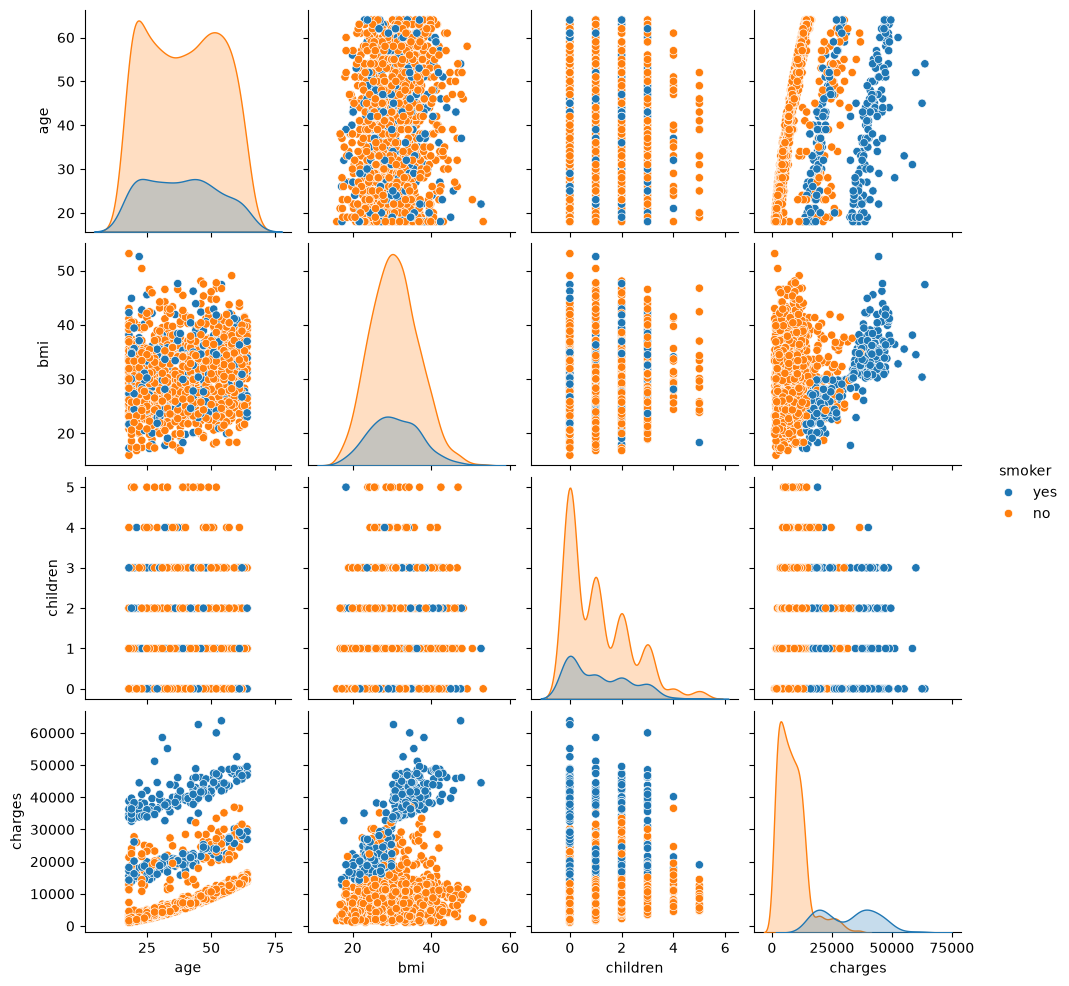

In [9]:
## Understanding relationship between variables
sns.pairplot(df, hue="smoker", vars=["age","bmi","children","charges"])
plt.show()

Charges show a positive relationship with age and BMI, with higher charges generally associated with older individuals and those with higher BMI. Smokers have much higher charges than non-smokers, forming a cluster in the scatter plots. This indicates that smoking is the strongest factor affecting insurance charges. There is no clear relationship between the number of children and charges, as charges are widely distributed across all values of children. The distributions of age, BMI, and children are similar for smokers and non-smokers, suggesting that these features alone do not clearly separate the two groups. The distribution of charges is right-skewed, especially for non-smokers, while smokers exhibit a wider spread and substantially higher charge values. Overall, the pairplot indicates that smoking has the greatest impact on medical charges, while age and BMI have moderate positive relationships, and children have little observable effect.

Text(0.5, 1.0, 'Numeric feature correlation')

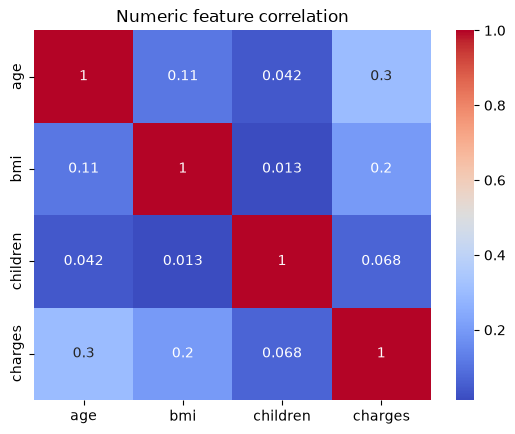

In [10]:
corr = df[["age", "bmi", "children", "charges"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Numeric feature correlation")

From the graph, i can tell that age has the most correlation with charges, while children has the least correlation.

# 3. Data Preparation

## 3.1 Data Cleaning

In [5]:
## Clean data
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

Duplicate rows: 1


removal of duplicate row to prevent data leakage

In [6]:
## Check datatypes for each column
col_categorical = df.select_dtypes(include=['object']).columns ## Select all categorical columns

## Print data about categorical column
'''
nunique(): Return total number of unique values in column
unique(): Return unique values in column
'''
for col in df[col_categorical]:
    print(f'{col} ({df[col].nunique()}): {df[col].unique()}') 

sex (2): <ArrowStringArray>
['female', 'male']
Length: 2, dtype: str
smoker (2): <ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str
region (4): <ArrowStringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str


C:\Users\mcafb\AppData\Local\Temp\ipykernel_41096\1766632001.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  col_categorical = df.select_dtypes(include=['object']).columns ## Select all categorical columns


In [7]:
y = df[col_y] ## Target variable
X = df.drop(columns=[col_y]) ## Features
X = pd.get_dummies(X,
columns=["sex", "smoker", "region"],
drop_first=True
)
X

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,False,True,False,False,True
1,18,33.770,1,True,False,False,True,False
2,28,33.000,3,True,False,False,True,False
3,33,22.705,0,True,False,True,False,False
4,32,28.880,0,True,False,True,False,False
...,...,...,...,...,...,...,...,...
1332,50,30.970,3,True,False,True,False,False
1333,18,31.920,0,False,False,False,False,False
1334,18,36.850,0,False,False,False,True,False
1335,21,25.800,0,False,False,False,False,True


## 3.2 Train-Test Split

In [8]:
## Split data into train set and test set
test_size = 0.3 
random_state = 2026 ## For reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=test_size, 
                                                    random_state=random_state)


In [9]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape 
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (935, 8)
X_test shape: (402, 8)
y_train shape: (935,)
y_test shape: (402,)


# 4. Modelling

### 4.2 Train Model

In [10]:
## Initialise and train model
model = LinearRegression()
model.fit(X_train, y_train)
## Evaluate model
y_pred_model = model.predict(X_test)
print("Linear Regression MSE: ", mean_squared_error(y_test, y_pred_model))
print("Linear Regression R²: ", r2_score(y_test, y_pred_model))
print("Train MSE:", mean_squared_error(y_train, model.predict(X_train)))
print("Train R²:", model.score(X_train, y_train))

Linear Regression MSE:  34555462.74829352
Linear Regression R²:  0.7649945498172601
Train MSE: 37486061.365913056
Train R²: 0.7438416516736986


In [11]:
## Initialise model
dt = DecisionTreeRegressor() ## Decision Tree Regressor model
dt.fit(X_train, y_train) ## Train model

y_pred_dt = dt.predict(X_test)
print("Decision Tree MSE: ", mean_squared_error(y_test, y_pred_dt))
print("Decision Tree R²: ", r2_score(y_test, y_pred_dt))
print("Train MSE:", mean_squared_error(y_train, dt.predict(X_train)))
print("Train R²:", dt.score(X_train, y_train))

Decision Tree MSE:  45699660.15325989
Decision Tree R²:  0.6892048795368708
Train MSE: 83572.41456149405
Train R²: 0.9994289138175723


In [12]:
rf = RandomForestRegressor(random_state=random_state)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("Random Forest MSE:", mean_squared_error(y_test, y_pred_rf))
print("Random Forest R²:", r2_score(y_test, y_pred_rf))
print("Train MSE:", mean_squared_error(y_train, rf.predict(X_train)))
print("Train R²:", rf.score(X_train, y_train))

Random Forest MSE: 20288638.87020417
Random Forest R²: 0.8620206377782389
Train MSE: 3669705.7180329515
Train R²: 0.9749233255956388


In [13]:
from sklearn.ensemble import GradientBoostingRegressor

## ===== Baseline Gradient Boosting =====
gb = GradientBoostingRegressor(random_state=random_state)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
print("Gradient Boosting Test MSE:", mean_squared_error(y_test, y_pred_gb))
print("Gradient Boosting Test R²:", r2_score(y_test, y_pred_gb))
print("Gradient Boosting Train R²:", gb.score(X_train, y_train))
print("Gradient Boosting Train MSE:", mean_squared_error(y_train, gb.predict(X_train)))

Gradient Boosting Test MSE: 18243830.037571646
Gradient Boosting Test R²: 0.8759270126906737
Gradient Boosting Train R²: 0.9002043028689707
Gradient Boosting Train MSE: 14604043.362828525


# 5. Model Evaluation

MSE and R² capture both how large the model's prediction errors are (MSE) and how well the model explains the overall variation in charges on an easily comparable 0–1 scale (R²), which is enough to reliably rank and select between models. Extra metrics like RMSE or MAE would convey the same information already captured by MSE, just rescaled or with lesser sensitivity to outliers. As this dataset has alot of outliers, MSE will be helpful in penalising outliers.

#explain why mse over mae/rmse, linking to use case

In [14]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'Test MSE': [mean_squared_error(y_test, y_pred_model), mean_squared_error(y_test, y_pred_dt),
                 mean_squared_error(y_test, y_pred_rf), mean_squared_error(y_test, y_pred_gb)],
    'Test R²': [r2_score(y_test, y_pred_model), r2_score(y_test, y_pred_dt),
                r2_score(y_test, y_pred_rf), r2_score(y_test, y_pred_gb)],
    'Train MSE': [mean_squared_error(y_train, model.predict(X_train)), mean_squared_error(y_train, dt.predict(X_train)),
                  mean_squared_error(y_train, rf.predict(X_train)), mean_squared_error(y_train, gb.predict(X_train))],
    'Train R²': [model.score(X_train, y_train), dt.score(X_train, y_train),
                 rf.score(X_train, y_train), gb.score(X_train, y_train)]
})
results

,Model,Test MSE,Test R²,Train MSE,Train R²
0,Linear Regression,3.455546e+07,0.764995,3.748606e+07,0.743842
1,Decision Tree,4.569966e+07,0.689205,8.357241e+04,0.999429
2,Random Forest,2.028864e+07,0.862021,3.669706e+06,0.974923
3,Gradient Boosting,1.824383e+07,0.875927,1.460404e+07,0.900204


Gradient Boosting has the best performance (Test R² = 0.875927, Test MSE = 1.824383e+07), outperforming Random Forest (Test R² = 0.862021, Test MSE = 2.028864e+07), Linear Regression, which underfit the data as it is unable to capture nonlinear feature interactions, and the single Decision Tree, which overfit (Train R² = 0.999429 vs Test R² = 0.690016) by memorizing the training data rather than learning patterns.

## Iterative model development


#tuning

In [15]:
param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'min_samples_split': [2, 5],
    'subsample': [0.8, 1.0]
}

gs_gb = GridSearchCV(estimator=gb,
                     param_grid=param_grid_gb,
                     cv=5,
                     scoring='r2',
                     n_jobs=-1)

gs_gb.fit(X_train, y_train)

best_gs_gb = gs_gb.best_estimator_
print("Best Parameters: ", gs_gb.best_params_)

y_pred_gs_gb = best_gs_gb.predict(X_test)
print("Grid Search Gradient Boosting R²: ", r2_score(y_test, y_pred_gs_gb))
print("Grid Search Gradient Boosting MSE: ", mean_squared_error(y_test, y_pred_gs_gb))
print("Train R²:", best_gs_gb.score(X_train, y_train))
print("Train MSE:", mean_squared_error(y_train, best_gs_gb.predict(X_train)))

Best Parameters:  {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100, 'subsample': 0.8}
Grid Search Gradient Boosting R²:  0.8784078544116224
Grid Search Gradient Boosting MSE:  17879044.311938517
Train R²: 0.8846831548930875
Train MSE: 16875398.988342743


In [16]:
from scipy.stats import randint, uniform

## Define parameter distribution
param_dist_gb = {
    'n_estimators': randint(100, 500),
    'learning_rate': uniform(0.01, 0.19),   ## range [0.01, 0.2)
    'max_depth': randint(2, 6),
    'min_samples_split': randint(2, 10),
    'subsample': uniform(0.6, 0.4)          ## range [0.6, 1.0)
}

rs_gb = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_dist_gb,
    cv=5,
    scoring='r2',
    n_iter=10,
    n_jobs=-1,
    random_state=random_state  ## for reproducibility
)

rs_gb.fit(X_train, y_train)

## Obtain best parameters and best estimator
best_rs_params_gb = rs_gb.best_params_
best_rs_gb = rs_gb.best_estimator_
print("Best Parameters: ", best_rs_params_gb)
print("Best Estimator: ", best_rs_gb)

## Evaluate model
y_pred_rs_gb = best_rs_gb.predict(X_test)
print("Randomized Search Gradient Boosting R²: ", r2_score(y_test, y_pred_rs_gb))
print("Randomized Search Gradient Boosting MSE: ", mean_squared_error(y_test, y_pred_rs_gb))
print("Train R²:", best_rs_gb.score(X_train, y_train))
print("Train MSE:", mean_squared_error(y_train, best_rs_gb.predict(X_train)))

Best Parameters:  {'learning_rate': np.float64(0.1061469875926603), 'max_depth': 2, 'min_samples_split': 7, 'n_estimators': 201, 'subsample': np.float64(0.8032113122799334)}
Best Estimator:  GradientBoostingRegressor(learning_rate=np.float64(0.1061469875926603),
                          max_depth=2, min_samples_split=7, n_estimators=201,
                          random_state=2026,
                          subsample=np.float64(0.8032113122799334))
Randomized Search Gradient Boosting R²:  0.8780889536419774
Randomized Search Gradient Boosting MSE:  17925935.835761905
Train R²: 0.8942262895191961
Train MSE: 15478862.304862158


Grid search has a higher R² score (test grid R² = 0.8784078544116224) compared to randomised search (test randomised R² = 0.8780889536419774), which means that grid search is able to account for a higher percentage of variation in charges. Grid also has a lower MSE (test grid MSE = 17879044.311938517) compared to randomised search (test randomised search MSE = 17925935.835761905). Although grid is better, due to the specification of this project, I will proceed with the randomised search.

#compare before and after randomisedsearchcv, comment on performance

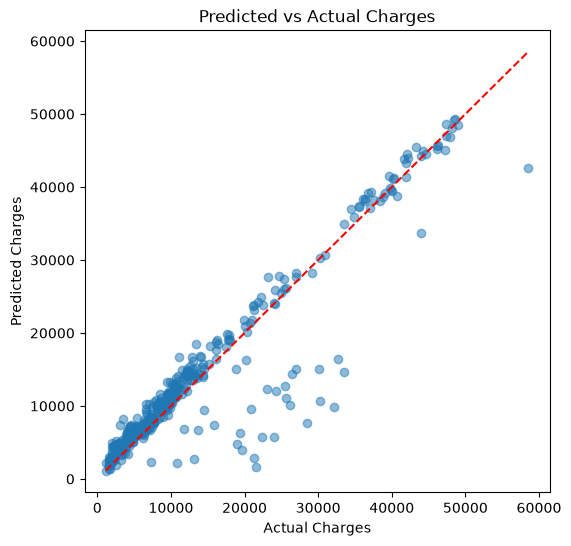

In [17]:
## Evaluate model
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rs_gb, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  ## perfect prediction line
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Predicted vs Actual Charges")
plt.show()

the chart shows that majority of the predictions track closely to the actual charges,however there are underpredictions at the $5000 to $35000 range.

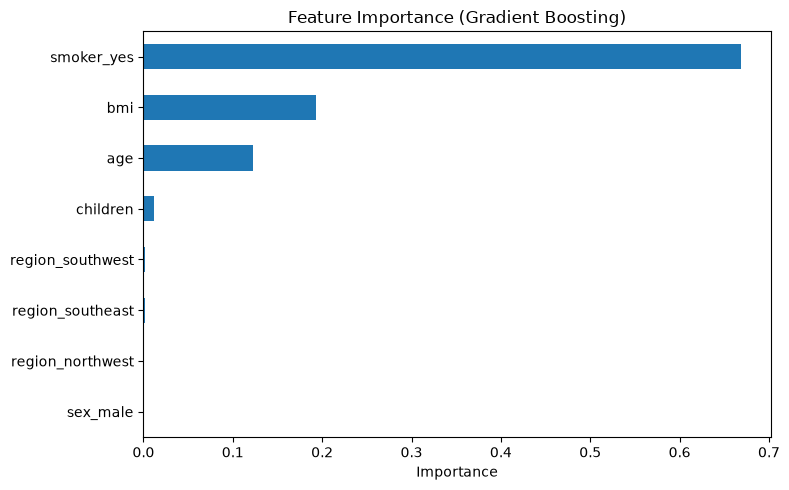

In [18]:
## Further feature engineering / feature selection
importances = pd.Series(best_rs_gb.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False)
plt.figure(figsize=(8, 5))
importances.sort_values(ascending=True).plot(kind='barh')
plt.xlabel("Importance")
plt.title("Feature Importance (Gradient Boosting)")
plt.tight_layout()
plt.show()


The sex and regions are of very low importance, therefore, removing them should improve the model.

In [19]:
## Save the full-feature Gradient Boosting results before overwriting X_train/X_test
X_train_full, X_test_full, y_train_full, y_test_full = X_train, X_test, y_train, y_test
y_pred_rs_gb_full = y_pred_rs_gb
best_rs_gb_full = best_rs_gb

## Drop features
cols_to_drop = ["region_northwest", "region_southeast", "region_southwest", "sex_male"]
X_reduced = X.drop(columns=cols_to_drop)

## Re-split using reduced features
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=test_size, random_state=random_state
)

## Re-run Randomized Search on Gradient Boosting with reduced features
rs_gb_reduced = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_dist_gb,
    cv=5,
    scoring='r2',
    n_iter=10,
    n_jobs=-1,
    random_state=random_state
)

rs_gb_reduced.fit(X_train, y_train)

best_rs_params_reduced = rs_gb_reduced.best_params_
best_rs_gb_reduced = rs_gb_reduced.best_estimator_
print("Best Parameters (reduced features): ", best_rs_params_reduced)

y_pred_rs_gb_reduced = best_rs_gb_reduced.predict(X_test)
print("Reduced-Feature Gradient Boosting R²: ", r2_score(y_test, y_pred_rs_gb_reduced))
print("Reduced-Feature Gradient Boosting MSE: ", mean_squared_error(y_test, y_pred_rs_gb_reduced))
print("Train R²: ", best_rs_gb_reduced.score(X_train, y_train))
print("Train MSE: ", mean_squared_error(y_train, best_rs_gb_reduced.predict(X_train)))

Best Parameters (reduced features):  {'learning_rate': np.float64(0.1061469875926603), 'max_depth': 2, 'min_samples_split': 7, 'n_estimators': 201, 'subsample': np.float64(0.8032113122799334)}
Reduced-Feature Gradient Boosting R²:  0.8747299809582033
Reduced-Feature Gradient Boosting MSE:  18419842.914752766
Train R²:  0.8938113836316008
Train MSE:  15539579.387342969


In [20]:
cols_to_drop_v2 = ["children"]   ## <-- change this each time you try something new
X_reduced_v2 = X.drop(columns=cols_to_drop_v2)

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_reduced_v2, y, test_size=test_size, random_state=random_state
)

rs_gb_v2 = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_dist_gb,
    cv=5,
    scoring='r2',
    n_iter=10,
    n_jobs=-1,
    random_state=random_state
)

rs_gb_v2.fit(X_train_v2, y_train_v2)
best_rs_gb_v2 = rs_gb_v2.best_estimator_
print("Best Parameters (v2): ", rs_gb_v2.best_params_)

y_pred_rs_gb_v2 = best_rs_gb_v2.predict(X_test_v2)
print("v2 R²: ", r2_score(y_test_v2, y_pred_rs_gb_v2))
print("v2 MSE: ", mean_squared_error(y_test_v2, y_pred_rs_gb_v2))
print("v2 train R²: ", best_rs_gb_v2.score(X_train_v2, y_train_v2))
print("v2 train MSE: ", mean_squared_error(y_train_v2, best_rs_gb_v2.predict(X_train_v2)))

Best Parameters (v2):  {'learning_rate': np.float64(0.1061469875926603), 'max_depth': 2, 'min_samples_split': 7, 'n_estimators': 201, 'subsample': np.float64(0.8032113122799334)}
v2 R²:  0.8709785325432924
v2 MSE:  18971460.061728705
v2 train R²:  0.8865319597253314
v2 train MSE:  16604845.981392482


In [22]:
cols_to_drop_v3 = ["sex_male"]   ## drop only sex this time
X_reduced_v3 = X.drop(columns=cols_to_drop_v3)

X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(
    X_reduced_v3, y, test_size=test_size, random_state=random_state
)

rs_gb_v3 = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_dist_gb,
    cv=5,
    scoring='r2',
    n_iter=10,
    n_jobs=-1,
    random_state=random_state
)

rs_gb_v3.fit(X_train_v3, y_train_v3)
best_rs_gb_v3 = rs_gb_v3.best_estimator_
print("Best Parameters (dropped sex only): ", rs_gb_v3.best_params_)

y_pred_rs_gb_v3 = best_rs_gb_v3.predict(X_test_v3)
print("v3 R²: ", r2_score(y_test_v3, y_pred_rs_gb_v3))
print("v3 MSE: ", mean_squared_error(y_test_v3, y_pred_rs_gb_v3))
print("v3 train R²: ", best_rs_gb_v3.score(X_train_v3, y_train_v3))
print("v3 train MSE: ", mean_squared_error(y_train_v3, best_rs_gb_v3.predict(X_train_v3)))

Best Parameters (dropped sex only):  {'learning_rate': np.float64(0.1061469875926603), 'max_depth': 2, 'min_samples_split': 7, 'n_estimators': 201, 'subsample': np.float64(0.8032113122799334)}
v3 R²:  0.8766088990331826
v3 MSE:  18143564.711432133
v3 train R²:  0.8934901544075309
v3 train MSE:  15586587.882223926


In [23]:
comparison_table = pd.concat([comparison_table, pd.DataFrame({
    'Model': ['Randomized Search GB (Dropped Sex Only)'],
    'Test R²': [r2_score(y_test_v3, y_pred_rs_gb_v3)],
    'Test MSE': [mean_squared_error(y_test_v3, y_pred_rs_gb_v3)],
    'Train R²': [best_rs_gb_v3.score(X_train_v3, y_train_v3)],
    'Train MSE': [mean_squared_error(y_train_v3, best_rs_gb_v3.predict(X_train_v3))]
})], ignore_index=True)

comparison_table


,Model,Test R²,Test MSE,Train R²,Train MSE
0,Randomized Search GB (Full Features),0.878089,1.792594e+07,0.894226,1.547886e+07
1,Randomized Search GB (Dropped Region + Sex),0.874730,1.841984e+07,0.893811,1.553958e+07
2,Randomized Search GB (Dropped Children),0.870979,1.897146e+07,0.886532,1.660485e+07
3,Randomized Search GB (Dropped Sex Only),0.876609,1.814356e+07,0.893490,1.558659e+07


Dropping region and sex slightly reduced the model's Test R² and increased the Test MSE compared to the full-feature model. Dropping children on top of the other two reduced the Test R² further and increased the Test MSE again. Dropping only sex performed better than dropping both region and sex but was still slightly worse than the full-feature model. Therefore, the model using all original features performed best out of the four and will be used.


Final settings 
'n_estimators': randint(100, 500),
'learning_rate': uniform(0.01, 0.19),   range [0.01, 0.2)
'max_depth': randint(2, 6),
'min_samples_split': randint(2, 10),
'subsample': uniform(0.6, 0.4)     range [0.6, 1.0)
cv=5,
scoring='r2',
n_iter=10,
n_jobs=-1,
random_state=random_stat

In [24]:
import joblib
joblib.dump(best_rs_gb, 'insurance_model.pkl')

['insurance_model.pkl']